In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u
import astropy.constants as const
from astropy.table import Table, QTable
from astropy.visualization import quantity_support
quantity_support()  


import sys, os
from pathlib import Path

# 设置路径为 project 的路径。按需调整
project_path = Path('~/Codes/JWST_LRD_SED/LRD_dust_modeling').expanduser()
os.chdir(project_path)

# 添加 src 目录到 sys.path
module_path = project_path / 'src'
sys.path.insert(0, str(module_path))
from LRD_IR_spectrum import *

# u.set_enabled_equivalencies(u.spectral())  # enable convenient equivalencies for converting between nu, lambda

In [75]:
# deep reload LRD_IR_spectrum
import LRD_IR_spectrum
deep_reload(LRD_IR_spectrum)
from LRD_IR_spectrum import *

## Data

### Orion Opacity, Temple SED

In [ ]:
Orion_opacity = OpacityData('data/raw/Orion_Tdust20_Sigma_23_Thickness_16_Hden_07.opc')
Temple_SED = SED.from_file('data/raw/quasar5.template')
# Temple_SED = SED.from_file('data/raw/quasar5_ly.template')

/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [3]:
Temple_SED.nu, Temple_SED.L_nu

(<Quantity [2.99792458e+13, 9.92706128e+13, 9.92881007e+13, ...,
            3.36254189e+15, 3.36313424e+15, 3.36372670e+15] Hz>,
 <Quantity [2.29599253e+29, 4.57075172e+29, 4.57122919e+29, ...,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>)

### Labbe photometric data

In [4]:
Labbe_photo_raw = Table.read('data/raw/Labbe_photo.dat', format='ascii', names=['lg_lambda', 'lg_nu_L_nu'], )
Labbe_photo = QTable({'wavelength_obs': 10**Labbe_photo_raw['lg_lambda'] * u.micron, 
                      'nu_L_nu': 10**Labbe_photo_raw['lg_nu_L_nu'] * u.Lsun},
                     meta={'z': 4.4655, })
# Labbe_photo.meta = {'z': 4.4655, }
Labbe_photo['wavelength_rest'] = Labbe_photo['wavelength_obs'] / (1 + Labbe_photo.meta['z'])
Labbe_photo['nu_obs'] = Labbe_photo['wavelength_obs'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['nu_rest'] = Labbe_photo['wavelength_rest'].to(u.Hz, equivalencies=u.spectral())
Labbe_photo['Lnu_obs'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_obs']
Labbe_photo['Lnu_rest'] = Labbe_photo['nu_L_nu'] / Labbe_photo['nu_rest']

In [5]:
Labbe_photo

wavelength_obs,nu_L_nu,wavelength_rest,nu_obs,nu_rest,Lnu_obs,Lnu_rest
micron,solLum,micron,Hz,Hz,solLum / Hz,solLum / Hz
float64,float64,float64,float64,float64,float64,float64
0.7019960960111995,8312047745.422186,0.1284413312617692,427057158442113.56,2334080899465371.0,1.9463548569807807e-05,3.561165230959256e-06
0.899984029546824,16837490832.18056,0.16466636712959914,333108642106634.75,1820605283433812.0,5.0546544591870847e-05,9.248292853695152e-06
1.1498548924823908,18624001274.96198,0.2103842086693607,260721991931335.03,1424976046900711.5,7.143241403228802e-05,1.3069694269927365e-05
1.4043754647291624,25203441893.940323,0.2569527883504094,213470304437293.62,1166721948902028.0,0.00011806532979084111,2.1601926592414442e-05
1.4930744380738064,25203441893.940323,0.27318167378534564,200788688330072.75,1097410576068012.4,0.00012552221991962446,2.296628303350553e-05
1.6235331166307188,22406032599.149887,0.2970511603020252,184654353477034.38,1009228368928731.2,0.00012134039721915652,2.220115217622478e-05
1.846840196204909,18624001274.96198,0.33790873592624815,162327232543479.72,887199489466388.4,0.00011473121905145212,2.099189809742057e-05
1.9765326632949234,30835507096.780453,0.3616380318900235,151675944226613.2,828984873170554.2,0.00020329859988021772,3.7196706592300384e-05


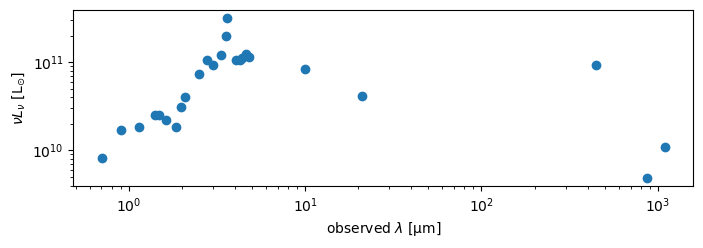

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x='wavelength_obs', y='nu_L_nu', data=Labbe_photo, )
ax.set_xlabel(fr'observed $\lambda$ [{ax.get_xlabel()}]') 
ax.set_ylabel(fr'$\nu L_\nu$ [{ax.get_ylabel()}]') 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect(.5)
# ax = plt.gca()

## Model

### B87

In [81]:
model = B87Model(n_0= 1e2 * u.cm**-3, gamma=0, L_UV=1e46 * u.erg / u.s, T_sub= 1500 * u.K, NH_target= 7.5e22 * u.cm**-2, opacity=Orion_opacity,)
# model.method_L_nu = 'quad'
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [4.61991861e+09, 4.67990071e+09, 4.75022047e+09, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [82]:
model

In [11]:
model.IR_Flux(1000 * u.K) 

<Quantity 3.42219478e-16 erg / s>

### SemiOrion

In [83]:
model = SemiOrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, L_UV=1e46 * u.erg/u.s, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, )
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [8.84205899e+08, 8.95685869e+08, 9.09144359e+08, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [84]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [52]:
model.IR_Flux(1000 * u.K, method='trapz', )

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity 3.86279682e-16 erg / s>

### Orion

In [85]:
model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED)
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [2.01420195e+09, 2.04035306e+09, 2.07101120e+09, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [86]:
model.tau_ph =0
(model.calc_L_nu() * model.opacity.nu).max()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity 1.91575331e+45 erg / s>

In [87]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


(np.float64(1e+40), np.float64(1e+48))

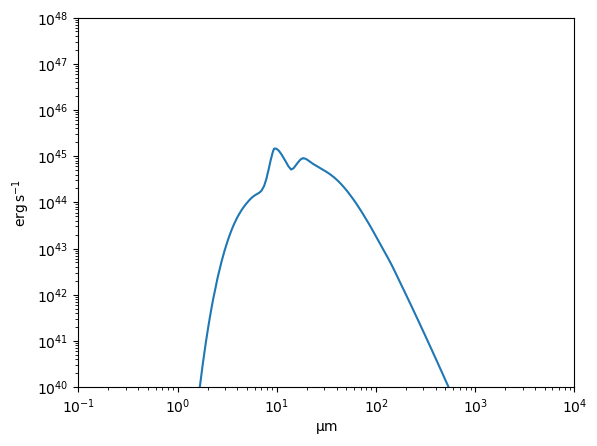

In [105]:
model.tau_ph =1
plt.loglog(model.opacity.wavelength, model.calc_L_nu() * model.opacity.nu)

plt.xlim(1e-1*u.micron, 1e4 * u.micron)
plt.ylim(*[1e40,1e48]*u.erg/u.s)

### A_V Model

In [ ]:
model = A_V_Model(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, A_V=3 * u.mag(), opacity=Orion_opacity, observed_SED=SED(nu=Labbe_photo['nu_rest'], L_nu=Labbe_photo['Lnu_rest']))
model.calc_L_nu()

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [1.15067876e+09, 1.16561845e+09, 1.18313292e+09, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / (Hz s)>

In [91]:
model.tau_ph = 0

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


Text(0.5, 1.0, 'A_V_Model( $n_0=$ $1000 \\; \\mathrm{cm^{-3}}$, $\\gamma=0.5$, \n        $A_V=$ $3 \\; \\mathrm{mag}$, $N_{\\rm H}=$ $7.43 \\times 10^{22} \\; \\mathrm{cm^{-2}}$, $\\tau_{\\rm ph}=0$, \n        $r_{\\rm in}=$ $1.033 \\; \\mathrm{pc}$, $r_{\\rm ph}=$ $1.033 \\; \\mathrm{pc}$, $r_{\\rm out}=$ $165.4 \\; \\mathrm{pc}$, \n        $T_{\\rm sub}=$ $1500 \\; \\mathrm{K}$, $T_{\\rm out}=$ $87.64 \\; \\mathrm{K}$ )\n        ')

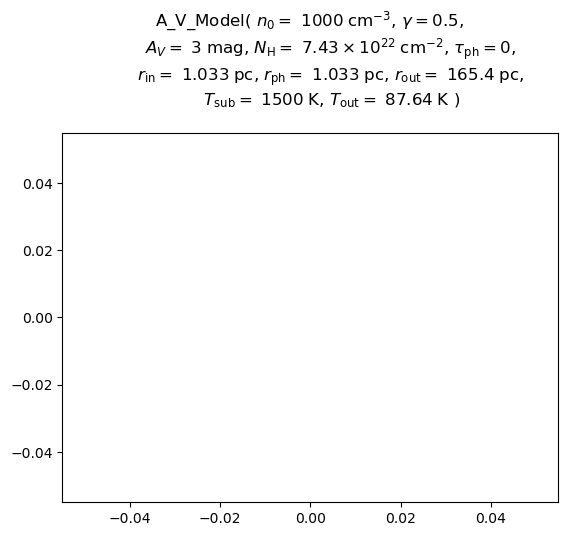

In [92]:
plt.plot()
plt.title(f'{model:latex}')

In [15]:
model.__dict__.keys()

dict_keys(['A_V', 'observed_SED', 'incident_SED', 'sigma_H_UV_ext', 'sigma_H_UV_abs', 'tau_ph', 'n_0', 'gamma', 'L_UV', 'T_sub', 'NH_target', 'opacity', 'r_in', '_r_out'])

In [17]:
model.L_UV

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


(1e+43, 1e+48)

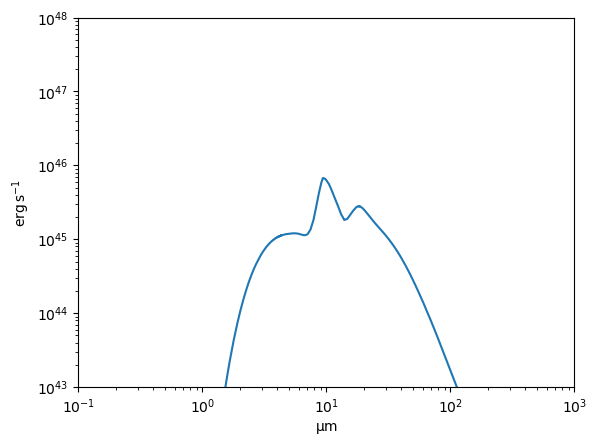

In [11]:
plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu())
plt.xlim(1e-1*u.micron, 1e3 * u.micron)
plt.ylim(1e43, 1e48)

In [47]:
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


## 测速

In [15]:
model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED, tau_ph=0)

In [13]:
np.seterr(all='ignore')
%timeit model.calc_L_nu(r_sample_num=1000)

510 ms ± 19.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### viztracer

In [18]:
%load_ext viztracer

In [19]:
%%viztracer
model.calc_L_nu(r_sample_num=1000)

Button(description='VizTracer Report', style=ButtonStyle())

In [28]:
model.calc_nu_L_nu()

<Quantity [2.01756174e+16, 2.05058302e+16, 2.08834445e+16, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00] erg / s>

## 和政融的 code 对比

In [ ]:
# 加载李政融版本的代码。因为两个包重名，需要清掉缓存再重新 import
# 把 LRD_IR_spectrum 及其子模块模块从 sys.modules 中删除，这样重新 import 时就不会从缓存中加载
for key in [key for key in sys.modules if key.startswith('LRD_IR_spectrum')]:
    sys.modules.pop(key)
    
sys.path.insert(0, str(project_path.parent / 'Li24LRDDustIRSED'))  # 添加 Li24LRDDustIRSED 目录到 sys.path
import LRD_IR_spectrum as ZL  # import 李政融的版本

In [ ]:
# 李政融那个版本的 IncidentSED 的 L_nu 不带单位，需要单独 mock 一下
sed = SED(nu=Temple_SED.nu, L_nu=Temple_SED.L_nu)
sed.L_nu = sed.L_nu.cgs.value
 
model_ZL = ZL.OrionLRDModel(n_0=1e3 , gamma=.9, T_sub=1500, NH_target=7.5e22, opacity=Orion_opacity, incident_SED=sed, L_UV=1e46 )
model_ZL.T_floor = 0   # 李政融设定 T_floor = 10 了。这里改过来

model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.9, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED, tau_ph=0)
# model.T_floor = 10 * u.K

In [ ]:
# 对比两者的计算速度
np.seterr(all='ignore')
%timeit model_ZL.calc_L_nu(r_sample_num=1000) * (u.pc.to(u.cm)**3) * u.erg/u.s/u.Hz * model_ZL.opacity.nu
%timeit model.calc_nu_L_nu(r_sample_num=1000)

390 ms ± 18.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
461 ms ± 14.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


(1e+40, 1e+48)

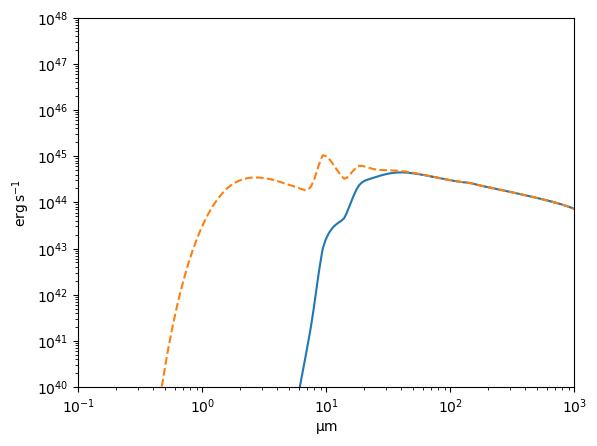

In [128]:
# 对比：no-feedback
L_nu_ZL = model_ZL.calc_L_nu(r_sample_num=1000) * (u.pc.to(u.cm)**3) * u.erg/u.s/u.Hz
nu_L_nu_ZL = L_nu_ZL * model_ZL.opacity.nu

plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu(r_sample_num=1000), label='Chen')
plt.loglog(model_ZL.opacity.wavelength, nu_L_nu_ZL, label='Li', ls='--')
plt.xlim(1e-1, 1e3)
plt.ylim(1e40, 1e48)

(1e+40, 1e+48)

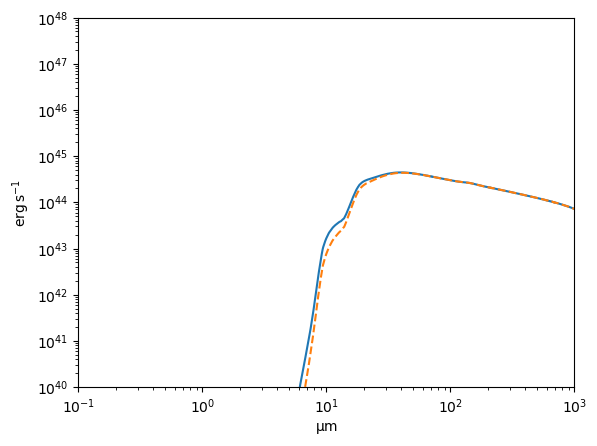

In [129]:
# 对比：feedback
L_nu_ZL = model_ZL.calc_L_nu_photon(r_sample_num=1000) * (u.pc.to(u.cm)**3) * u.erg/u.s/u.Hz
nu_L_nu_ZL = L_nu_ZL * model_ZL.opacity.nu

model.tau_ph = 1
plt.loglog(model.opacity.wavelength, model.calc_nu_L_nu(r_sample_num=1000), label='LRD_IR_spectrum')
plt.loglog(model_ZL.opacity.wavelength, nu_L_nu_ZL, label='Li24LRDDustIRSED', ls='--')
plt.xlim(1e-1, 1e3)
plt.ylim(1e40, 1e48)

## 临时测试

#### equivalencies

In [10]:
model.calc_nu_L_nu([1,2,3] * u.micron)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [1.78186784e+40, 1.00255260e+44, 6.35178766e+44] erg / s>

### warning

In [8]:
model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED, tau_ph=0)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [14]:
1/(np.exp(1e4) -1)

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_97537/4122174201.py:1: RuntimeWarning: overflow encountered in exp
  1/(np.exp(1e4) -1)


np.float64(0.0)

In [42]:
np.log(1e-10**5.6 * 1e-100)

np.float64(-359.2032745070711)

In [45]:
T_arr = np.arange(-1, 4) * u.K

In [49]:
np.where(T_arr < 0, 0.0, 1 * u.K)

<Quantity [0., 1., 1., 1., 1.] K>

In [52]:
0 * u.K == 0 * u.m

False

In [60]:
np.log(0)

/var/folders/79/44wj1nt100s89rhhrrq9frxr0000gn/T/ipykernel_97537/2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

In [53]:
model.IR_Flux(1e-8*u.K)

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity 0. erg / s>

In [59]:
model.UV_Flux(model.r_out * 1e9)

<Quantity 0. erg / s>

### mag

In [162]:
def foo(A):
    if isinstance(A, u.Quantity):
        if A.unit is u.one:
            print("warn")
    A = u.Magnitude(A)
    return -np.log(A.physical)

foo(3)
foo(u.Magnitude(3))
foo(1e-2*u.one)
foo(1e-2*u.one)
foo(-2 * u.dex())

warn
warn


<Quantity 4.60517019>

In [49]:
class Foo:
    def _repr_latex_(self):
        return r'$1 \; \mathrm{mag}$ $\mathrm{\left( \mathrm{} \right)}$'
        return rf'{u.Magnitude(1 * u.mag()):latex}'

In [41]:
class Foo:
    def __init__(self, A):
        self.A = A
    def _repr_latex_(self):
        return rf'Foo($A=${self.A:latex})'
    
Foo(3*u.dex )

Text(0.5, 1.0, 'Foo($A=$$3 \\; \\mathrm{mag}$)')

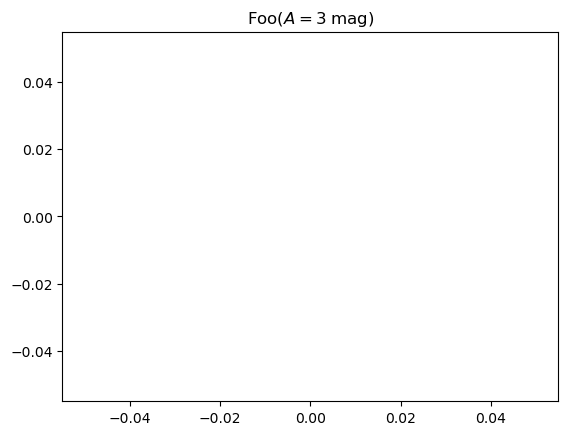

In [43]:
plt.plot()
plt.title(Foo(3 * u.mag)._repr_latex_())

### repr

In [8]:
model = B87Model(n_0= 1e2 * u.cm**-3, gamma=0, L_UV=1e46 * u.erg / u.s, T_sub= 1500 * u.K, NH_target= 7.5e22 * u.cm**-2, opacity=Orion_opacity,)
model

In [45]:
model = SemiOrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, L_UV=1e46 * u.erg/u.s, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, )
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [9]:
model = OrionLRDModel(n_0=1e3 * u.cm**-3, gamma=.5, T_sub=1500 * u.K, NH_target=7.5e22 * u.cm**-2, opacity=Orion_opacity, incident_SED=Temple_SED)
model

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


In [14]:
model.calc_nu_L_nu(([1,2,3]*u.micron).to('Hz', u.spectral()))

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


<Quantity [2.85847881e+34, 1.58878336e+41, 9.58918618e+42] erg / s>

/Users/chenkejian/miniconda3/envs/LRD/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/chenkejian/Codes/JWST_LRD_SED/LRD_dust_modeling/src/LRD_IR_spectrum/utils.py:71: RuntimeWarning: divide by zero encountered in log
  self._interp = interpolate.interp1d(self.f_x(x_value), self.f_y(y_value), **kwargs)


Text(0.5, 1.0, 'OrionLRDModel($n_0=$ $1000 \\; \\mathrm{cm^{-3}}$, $\\gamma=0.5$, \n        $T_{\\rm sub}=$ $1500 \\; \\mathrm{K}$, \n        $r_{\\rm in}=$ $0.5657 \\; \\mathrm{pc}$, $r_{\\rm out}=$ $286 \\; \\mathrm{pc}$, $T_{\\rm out}=$ $53.04 \\; \\mathrm{K}$)\n        ')

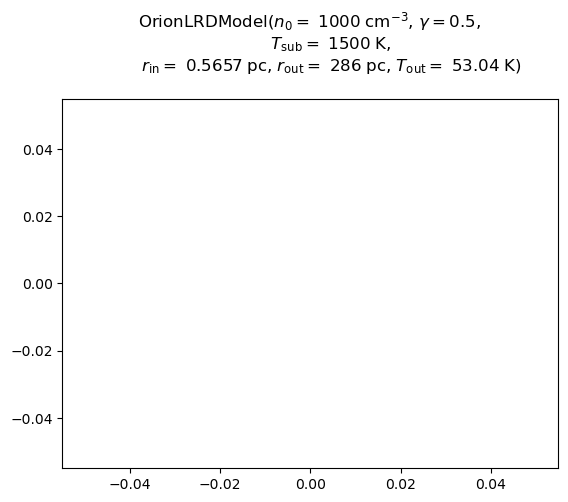

In [21]:
plt.plot()
# plt.title(rf"$r_\mathrm{{out}}=${model.r_out.to_string(format='latex', formatter='.3e')}")
# plt.title(rf"$r_\mathrm{{out}}=${model.r_out:.1f}")
plt.title(model._repr_latex_())

Text(0.5, 1.0, 'B87Model($n_0=$ $100 \\; \\mathrm{cm^{-3}}$ , $\\gamma=0$, \n        $L_{\\rm UV}=$ $1 \\times 10^{46} \\; \\mathrm{erg\\,s^{-1}}$ , $T_{\\rm sub}=$ $1500 \\; \\mathrm{K}$, \n        $r_{\\rm in}=$ $1.3 \\; \\mathrm{pc}$, $r_{\\rm out}=$ $244.4 \\; \\mathrm{pc}$ , $T_{\\rm out}=$ $92.88 \\; \\mathrm{K}$)\n        ')

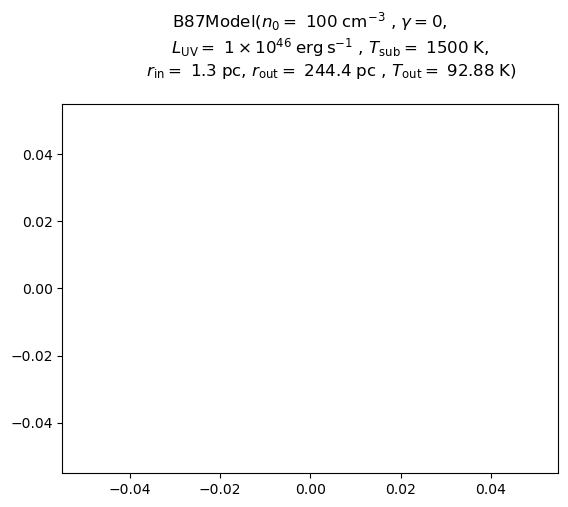

In [9]:
plt.plot()
# plt.title(rf"$r_\mathrm{{out}}=${model.r_out.to_string(format='latex', formatter='.3e')}")
# plt.title(rf"$r_\mathrm{{out}}=${model.r_out:.1f}")
plt.title(model._repr_latex_())

In [174]:
class Foo:
    
    # def __repr__(self):
    #     return f"Foo()"
    
    # def __format__(self, format_spec):
    #     if format_spec == 'latex':
    #         return "tst"
    #     else:
    #         return super().__format__(format_spec)
    
    def _repr_latex_(self):
        return rf"$a={1+2}$"

    pass
foo = Foo()
foo

In [175]:
model._repr_latex_

<bound method LRD_IR_ModelBase._repr_latex_ of B87Model(n_0=100.0 1 / cm3, gamma=0, L_UV=1e+46 erg / s, T_sub=1500.0 K, r_in=1.3 pc)>

In [222]:
LRD_IR_ModelBase._repr_latex_ = lambda self: rf"$r_\mathrm{{out}}=${self.r_out:latex}"
model

B87Model(n_0=100.0 1 / cm3, gamma=0, L_UV=1e+46 erg / s, T_sub=1500.0 K, r_in=1.3 pc)

Text(0.5, 1.0, '$r_0=$ $\\frac{1}{2} \\; \\mathrm{cm}$')

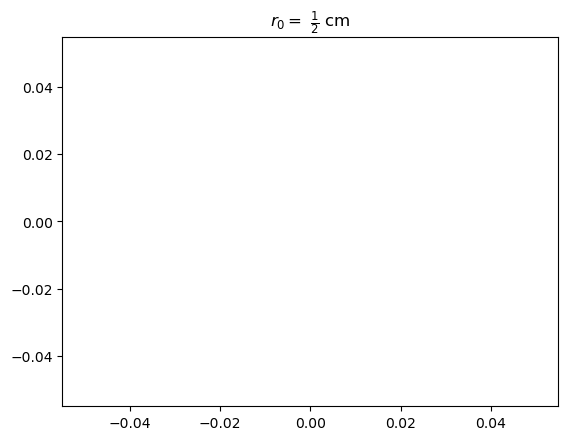

In [235]:
plt.plot()
plt.title(model._repr_latex_())
plt.title(r"$r_0=$ $\frac{1}{2} \; \mathrm{cm}$")

In [151]:
repr(foo)

'<__main__.Foo object at 0x32484b8c0>'

In [170]:
f"{foo:latex}"

TypeError: unsupported format string passed to Foo.__format__

In [160]:
f"{model}"

'B87Model(n_0=100.0 1 / cm3, gamma=0, L_UV=1e+46 erg / s, T_sub=1500.0 K, r_in=1.3 pc)'